# Computing Tercile Probabilities from ECMWF SEAS5 forecasts

This notebook is adapted from this [ECMWF documentation](https://ecmwf-projects.github.io/c3s-seasonal-forecasts/workflows/graphical_product_example_tmin.html#produce-tercile-summary). We walk though how one might calculate tercile probabilities from SEAS5 forecasts and calculate summary stats across administrative boundaries.

In [1]:
from datetime import datetime

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import earthkit.data
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray  # noqa
import xarray as xr
from dateutil.relativedelta import relativedelta
from exactextract import exact_extract
from fsspec.implementations.http import HTTPFileSystem

## 1. Calculate climatology

**Question**: What time period should we use to calculate this climatology? Should it be static or should it be rolling? We've pulled in data from 1993-2016, following [this example](https://ecmwf-projects.github.io/c3s-seasonal-forecasts/workflows/graphical_product_example_tmin.html#load-forecast-and-hindcast-data)."

In [27]:
variable = ["total_precipitation"]
product = ["monthly_mean"]
dataset = "seasonal-monthly-single-levels"
use_cache = True
cache_path = "/Users/hannahker/Downloads/hindcast.grib"

In [28]:
if use_cache:
    hcst = xr.open_dataset(
        cache_path,
        engine="cfgrib",
        chunks="auto",
        backend_kwargs=dict(
            time_dims=("time", "forecastMonth"), indexpath=("")
        ),
    )
else:
    request = {
        "originating_centre": "ecmwf",
        "system": "51",
        "variable": variable,
        "product_type": product,
        "year": [
            "1993",
            "1994",
            "1995",
            "1996",
            "1997",
            "1998",
            "1999",
            "2000",
            "2001",
            "2002",
            "2003",
            "2004",
            "2005",
            "2006",
            "2007",
            "2008",
            "2009",
            "2010",
            "2011",
            "2012",
            "2013",
            "2014",
            "2015",
            "2016",
        ],
        "month": [
            "01",
            "02",
            "03",
            "04",
            "05",
            "06",
            "07",
            "08",
            "09",
            "10",
            "11",
            "12",
        ],
        "leadtime_month": ["1", "2", "3", "4", "5", "6"],
        "data_format": "grib",
    }

    hcst = earthkit.data.from_source("cds", dataset, request).to_xarray(
        engine="cfgrib",
        backend_kwargs=dict(
            time_dims=("time", "forecastMonth"), indexpath=("")
        ),
    )

In [29]:
# Rename and convert longitude to [-180, 180]
hcst_ = hcst.rename(
    {"time": "start_date", "longitude": "lon", "latitude": "lat"}
)
hcst_ = hcst_.assign_coords(lon=(((hcst_.lon + 180) % 360) - 180)).sortby(
    "lon"
)
hcst_ = hcst_.tprate

In [30]:
# Compute quantiles
quantiles = [1.0 / 3.0, 2.0 / 3.0]
hcst_qbnds = hcst_.quantile(quantiles, ["start_date", "number"])

## 2. Download recent forecast

In [125]:
use_cache = True
cache_path = "/Users/hannahker/Downloads/forecast.grib"

now = datetime.now()
current_month = now.month
current_year = now.year
if use_cache:
    fcst = xr.open_dataset(
        cache_path,
        engine="cfgrib",
        chunks="auto",
        backend_kwargs=dict(
            time_dims=("time", "forecastMonth"),
            indexpath=(""),
            filter_by_keys={"dataType": "fcmean"},
        ),
    )
else:
    request = {
        "originating_centre": "ecmwf",
        "system": "51",
        "variable": [variable],
        "product_type": [product],
        "year": [str(current_year)],
        "month": [str(current_month).zfill(0)],
        "leadtime_month": ["1", "2", "3", "4", "5", "6"],
        "data_format": "grib",
    }

    fcst = earthkit.data.from_source("cds", dataset, request).to_xarray(
        engine="cfgrib",
        backend_kwargs=dict(
            time_dims=("time", "forecastMonth"), indexpath=("")
        ),
    )

In [126]:
# Rename and convert longitude to [-180, 180]
# TODO: Select ensemble members?
fcst = fcst.rename(
    {"time": "start_date", "longitude": "lon", "latitude": "lat"}
)
fcst = fcst.assign_coords(lon=(((fcst.lon + 180) % 360) - 180)).sortby("lon")
fcst = fcst.tprate

valid_time = [
    pd.to_datetime(fcst.start_date.values) + relativedelta(months=fcmonth - 1)
    for fcmonth in fcst.forecastMonth
]
fcst = fcst.assign_coords(valid_time=("forecastMonth", valid_time))

## 3. Calculate tercile summary from hindcasts

We calculate the tercile summary by taking the percentage of ensemble members in each tercile range. 

In [128]:
fc_ens = fcst.sizes["number"]

# For each grid point, count the number of ensemble members that are either
# above the upper tercile, or below the lower tercile
above = fcst.where(fcst > hcst_qbnds.sel(quantile=2.0 / 3.0)).count("number")
below = fcst.where(fcst < hcst_qbnds.sel(quantile=1.0 / 3.0)).count("number")

# Now convert the counts to probabilities
# Each are ranging from 0-100
P_above = 100.0 * (above / float(fc_ens))
P_below = 100.0 * (below / float(fc_ens))
P_normal = 100.0 - (P_above + P_below)

# Calculating a summary metric indicating the probability
# of the dominant tercile
a = P_above.where(P_above > np.maximum(40.0 + 0 * P_above, P_below), 0.0)
b = P_below.where(P_below > np.maximum(40.0 + 0 * P_below, P_above), 0.0)
P_summary = a - b

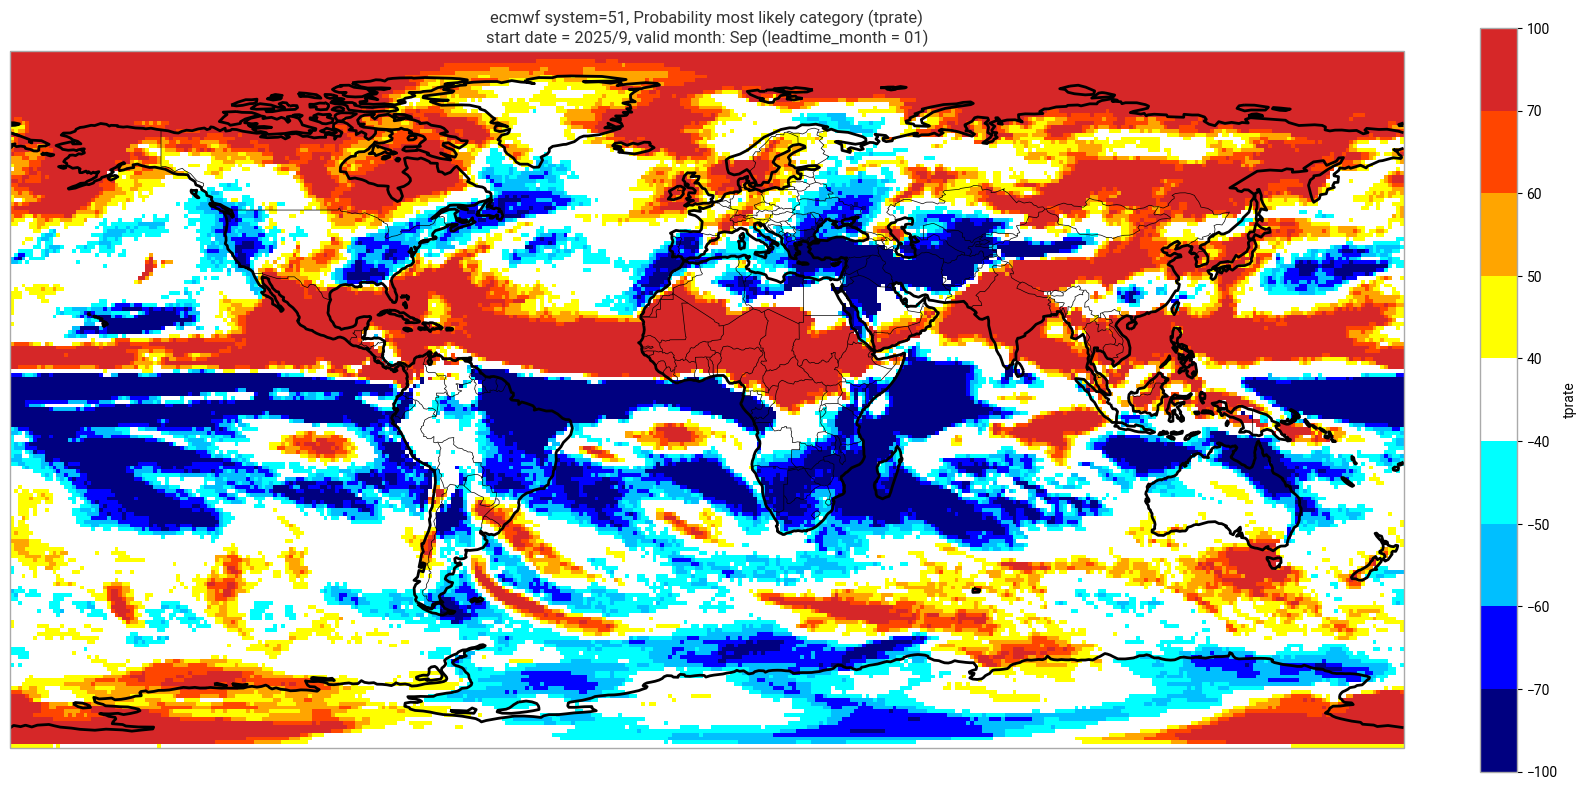

In [129]:
# Plot tercile summary
# levels to use when shading the plot, and corresponding colours
contour_levels = [
    -100.0,
    -70.0,
    -60.0,
    -50.0,
    -40.0,
    40.0,
    50.0,
    60.0,
    70.0,
    100.0,
]
contour_colours = [
    "navy",
    "blue",
    "deepskyblue",
    "cyan",
    "white",
    "yellow",
    "orange",
    "orangered",
    "tab:red",
]

center = "ecmwf"
version = "51"
var_str = "tprate"

start_date = pd.Timestamp(fcst.start_date.values)

lt_mons = [1]
for ltm in lt_mons:
    lt_str = str(ltm).zfill(2)
    plot_data = P_summary.sel(
        forecastMonth=ltm
    )  # extract the specific forecast month

    # clip the data to sit within levels range
    plot_data = plot_data.clip(min=-99, max=99)

    valid_time = pd.to_datetime(plot_data.valid_time.values)
    vm_str = valid_time.strftime("%b")  # valid month string to label the plot
    title_txt1 = f"{center} system={version}, Probability most likely category ({var_str})"
    title_txt2 = f"start date = {start_date.year}/{start_date.month}, valid month: {vm_str} (leadtime_month = {lt_str})"

    fig = plt.figure(figsize=(16, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=2.0)
    plot_data.plot(
        levels=contour_levels,
        colors=contour_colours,
        cbar_kwargs={"fraction": 0.033, "extend": "neither"},
    )
    plt.title(title_txt1 + "\n" + title_txt2)
    plt.tight_layout()

## 4. Take raster stats per admin level

We can summarize the tercile probability per administrative level as shown below. For each tercile, we calculate the average probability across a given admin boundary. We can highlight the "dominant" tercile per admin boundary by identifying the one that has the most likely probability (given that it is above a 40% threshold).

In [130]:
GLOBAL_ADM1 = "https://data.fieldmaps.io/edge-matched/humanitarian/intl/adm1_polygons.parquet"
GLOBAL_ADM0 = "https://data.fieldmaps.io/adm0/osm/intl/adm0_polygons.parquet"
ISO3 = "NGA"

filesystem = HTTPFileSystem()
filters = [("iso_3", "=", ISO3)]
gdf = gpd.read_parquet(GLOBAL_ADM1, filesystem=filesystem, filters=filters)

In [131]:
# Clip all rasters to the geodataframe and select a single forecast month
above_clipped = (
    P_above.rio.write_crs("EPSG:4326")
    .rio.set_spatial_dims("lon", "lat")
    .rio.clip(gdf.geometry)
)
above_clipped = above_clipped.sel(forecastMonth=1).compute()

below_clipped = (
    P_below.rio.write_crs("EPSG:4326")
    .rio.set_spatial_dims("lon", "lat")
    .rio.clip(gdf.geometry)
)
below_clipped = below_clipped.sel(forecastMonth=1).compute()

norm_clipped = (
    P_normal.rio.write_crs("EPSG:4326")
    .rio.set_spatial_dims("lon", "lat")
    .rio.clip(gdf.geometry)
)
norm_clipped = norm_clipped.sel(forecastMonth=1).compute()

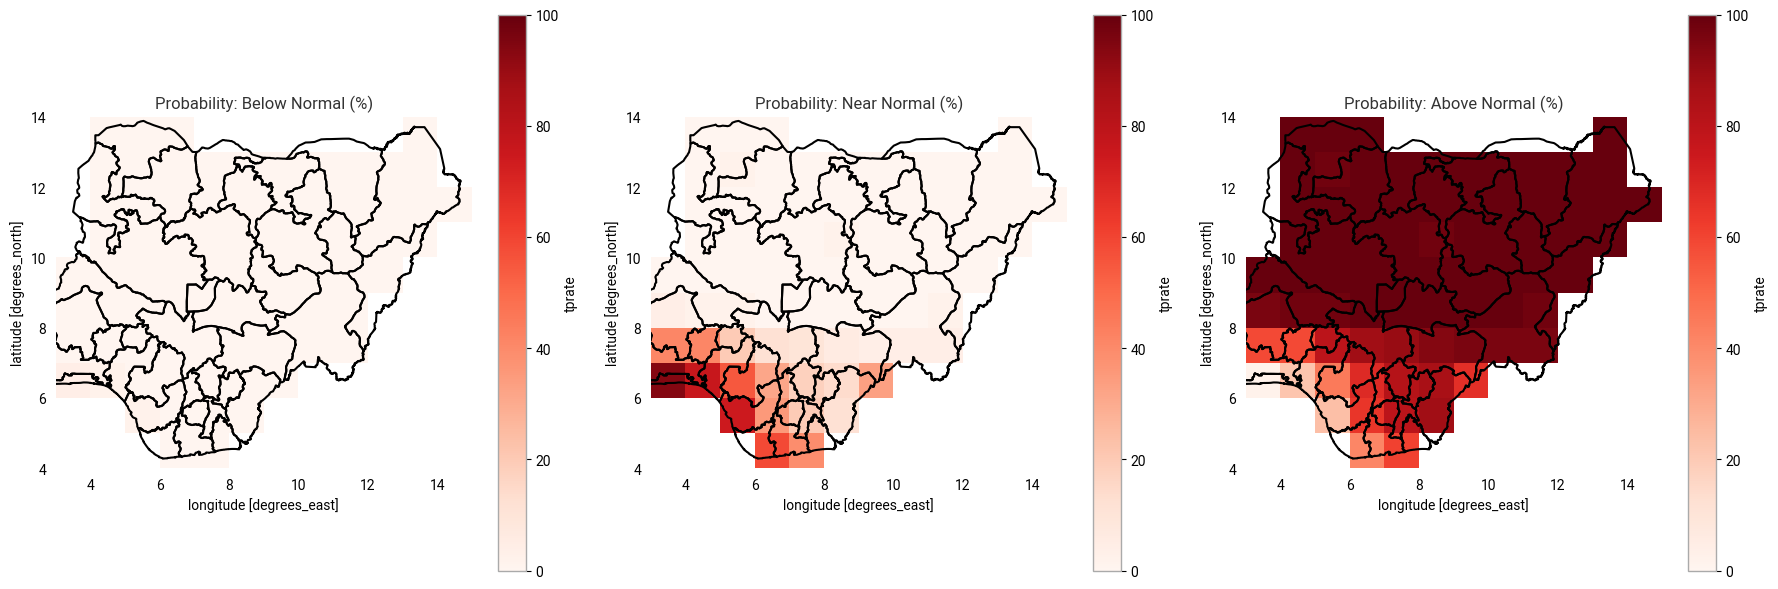

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (data, title) in zip(
    axes,
    [
        (below_clipped, "Below Normal"),
        (norm_clipped, "Near Normal"),
        (above_clipped, "Above Normal"),
    ],
):
    data.plot(ax=ax, cmap="Reds", vmin=0, vmax=100)
    gdf.boundary.plot(ax=ax, color="black", linewidth=1.5)
    ax.set_title(f"Probability: {title} (%)")

plt.tight_layout()
plt.show()

In [133]:
gdf_output = gdf[["adm1_src", "adm1_name", "geometry"]]

df_b = exact_extract(
    below_clipped,
    gdf_output,
    "mean",
    output="pandas",
    include_cols=["adm1_src", "adm1_name"],
)
df_b.rename(columns={"mean": "mean_prob_below"}, inplace=True)
gdf_output = gdf_output.merge(df_b)

df_a = exact_extract(
    above_clipped,
    gdf_output,
    "mean",
    output="pandas",
    include_cols=["adm1_src", "adm1_name"],
)
df_a.rename(columns={"mean": "mean_prob_above"}, inplace=True)
gdf_output = gdf_output.merge(df_a)

df_n = exact_extract(
    norm_clipped,
    gdf_output,
    "mean",
    output="pandas",
    include_cols=["adm1_src", "adm1_name"],
)
df_n.rename(columns={"mean": "mean_prob_norm"}, inplace=True)
gdf_output = gdf_output.merge(df_n)

/Users/hannahker/Desktop/PyPi/ocha-lens/venv/lib/python3.12/site-packages/exactextract/exact_extract.py:346: RuntimeWarning: Spatial reference system of input features does not exactly match raster.
  warnings.warn(
/Users/hannahker/Desktop/PyPi/ocha-lens/venv/lib/python3.12/site-packages/exactextract/exact_extract.py:346: RuntimeWarning: Spatial reference system of input features does not exactly match raster.
  warnings.warn(
/Users/hannahker/Desktop/PyPi/ocha-lens/venv/lib/python3.12/site-packages/exactextract/exact_extract.py:346: RuntimeWarning: Spatial reference system of input features does not exactly match raster.
  warnings.warn(


In [134]:
# Add dominant category column
gdf_output["dominant_category"] = (
    gdf_output[["mean_prob_below", "mean_prob_norm", "mean_prob_above"]]
    .idxmax(axis=1)
    .str.replace("mean_prob_", "")
)

# Add probability of dominant category
gdf_output["dominant_probability"] = gdf_output[
    ["mean_prob_below", "mean_prob_norm", "mean_prob_above"]
].max(axis=1)

In [135]:
# Calculate max probability and dominant category for all rows
max_prob = gdf_output[
    ["mean_prob_below", "mean_prob_norm", "mean_prob_above"]
].max(axis=1)
max_category = gdf_output[
    ["mean_prob_below", "mean_prob_norm", "mean_prob_above"]
].idxmax(axis=1)

# Apply 40% threshold
gdf_output["dominant_category"] = np.where(
    max_prob >= 40, max_category.str.replace("mean_prob_", ""), np.nan
)

gdf_output["dominant_probability"] = np.where(
    max_prob >= 40, max_prob.round(1), np.nan
)

In [136]:
gdf_output

,adm1_src,adm1_name,geometry,mean_prob_below,mean_prob_above,mean_prob_norm,dominant_category,dominant_probability
0,NG001,Abia,"MULTIPOLYGON (((7.47159 4.84228, 7.47438 4.836...",0.000000,78.332426,21.667574,above,78.3
1,NG002,Adamawa,"MULTIPOLYGON (((11.82258 7.42718, 11.83179 7.4...",0.000000,99.452470,0.547530,above,99.5
2,NG003,Akwa Ibom,"MULTIPOLYGON (((7.8094 4.51866, 7.81475 4.5195...",0.000000,69.931653,30.068347,above,69.9
3,NG004,Anambra,"MULTIPOLYGON (((6.80964 5.78031, 6.81421 5.777...",0.000000,72.284218,27.715782,above,72.3
4,NG005,Bauchi,"MULTIPOLYGON (((9.78145 9.55594, 9.78427 9.557...",0.000000,99.928531,0.071469,above,99.9
5,NG006,Bayelsa,"MULTIPOLYGON (((6.5627 4.32501, 6.56594 4.3249...",0.178411,44.730004,55.091585,norm,55.1
6,NG007,Benue,"MULTIPOLYGON (((7.83676 6.61486, 7.84403 6.608...",0.000000,90.659258,9.340742,above,90.7
7,NG008,Borno,"MULTIPOLYGON (((12.26275 10.2534, 12.26394 10....",0.000000,100.000000,0.000000,above,100.0
8,NG009,Cross River,"MULTIPOLYGON (((8.58421 4.80241, 8.58709 4.802...",0.000000,84.398417,15.601583,above,84.4
9,NG010,Delta,"MULTIPOLYGON (((5.9783 5.13331, 5.98089 5.1305...",0.989432,44.116824,54.893743,norm,54.9
